# Graduation

Graduation allows the rates to be smoothed from datapoints by minimizing a difference equation. There are 3 separate calculations in this workbook:
1. **1D smoothing** which will smooth on 1-axis, for instance year
2. **2D smoothing** which will smooth on 2-axis, for instance year and age
3. **Exponential smoothing** smooth by fitting a logistic regression using weighted least squares

A few notes on parameters:
- **order**: A higher order will allow more flexibility in curve
- **lamda**: A higher lamda will have a less flexible curve
- **normalize_weights**: Should be left as True, unless reason to have raw weights
- **expo**: when expo = 0 curve bends to polynomial when expo ≠ 0 bends to exponential
- **standard_rates**: blending the raw rates to the standard weights (used with standard_weights and blending factor)

Sources:
- http://www.howardfamily.ca/graduation/index.html
- https://arxiv.org/pdf/2306.06932
- Whittaker-Henderson-Lowrie

In [1]:
import os
import sys

import pandas as pd

os.chdir("../../")
sys.path.insert(0, os.getcwd())

In [2]:
from morai.experience import charters
from morai.forecast import graduation
from morai.utils import custom_logger

In [3]:
custom_logger.set_log_level("DEBUG")

In [4]:
# default is "plotly_mimetype+notebook", however that takes up space.
# "plotly_mimetype+notebook_connected" seems to save space
import plotly.io as pio
pio.renderers.default = "plotly_mimetype+notebook_connected"

## 1D

In [9]:
df = pd.read_csv("tests/files/forecast/graduation/simple_graduation_1d.csv")

In [11]:
df["grad_1"] = graduation.whl(
    rates=df["rate"],
    weights=df["exposure"],
    horizontal_order=3,
    horizontal_lambda=1,
    horizontal_expo=0,
    vertical_order=0,
    vertical_lambda=0,
    vertical_expo=0,
    normalize_weights=True,
)
df["grad_400"] = graduation.whl(
    rates=df["rate"],
    weights=df["exposure"],
    horizontal_order=3,
    horizontal_lambda=400,
    horizontal_expo=0,
    vertical_order=0,
    vertical_lambda=0,
    vertical_expo=0,
    normalize_weights=True,
)

In [12]:
df["grad_400"].sum()

np.float64(0.4336999999998473)

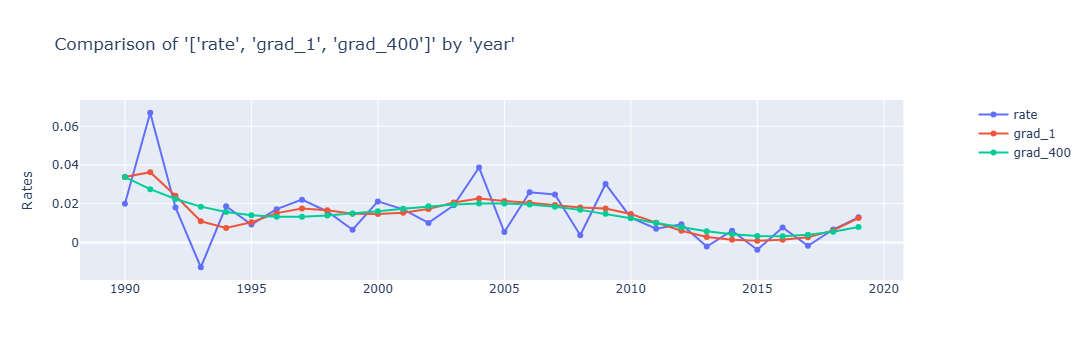

In [13]:
charters.compare_rates(
    df=df,
    x_axis="year",
    rates=["rate", "grad_1", "grad_400"],
    weights=None,
    y_log=False,
    # x_bins=6,
    display=True,
)

## 1D standard table blend

In [14]:
df = pd.read_csv("tests/files/forecast/graduation/simple_graduation_1d_age.csv")

In [13]:
df["grad_400"] = graduation.whl(
    rates=df["rate"],
    weights=df["exposure"],
    horizontal_order=3,
    horizontal_lambda=400,
    horizontal_expo=0,
    vertical_order=0,
    vertical_lambda=0,
    vertical_expo=0,
    normalize_weights=True,
    standard_rates=df["std"],
    standard_weights=df["std_weight"],
    blending_factor=.5
)

In [14]:
df["grad_400"].sum()

11.063216924199322

In [15]:
charters.compare_rates(
    df=df,
    x_axis="age",
    rates=["rate", "grad_400", "std"],
    weights=None,
    y_log=False,
    # x_bins=6,
    display=True,
)

## 2D

In [17]:
rates = pd.read_excel("tests/files/forecast/graduation/simple_graduation_2d.xlsx", "rates", index_col=0)
weights = pd.read_excel("tests/files/forecast/graduation/simple_graduation_2d.xlsx", "weights", index_col=0)

In [17]:
grad = graduation.whl(
    rates=rates,
    weights=weights,
    horizontal_order=2,
    horizontal_lambda=300,
    horizontal_expo=0,
    vertical_order=3,
    vertical_lambda=100,
    vertical_expo=0,
    normalize_weights=True,
)

In [18]:
grad.sum()

np.float64(5.615974451086855)

## Exponential

In [19]:
df = pd.read_csv("tests/files/forecast/graduation/simple_graduation_expo.csv")

In [20]:
df = df[(df["age"] >= 70) & (df["age"] <= 100)]
df_filter = df[(df["age"] >= 70) & (df["age"] <= 90)]
grad01 = graduation.exponential(
    rates=df_filter["rate"],
    weights=df_filter["exposure"],
    ages=df_filter["age"],
    expo_low=0,
    expo_high=1,
    calc_ages=df["age"],
)
grad11 = graduation.exponential(
    rates=df_filter["rate"],
    weights=df_filter["exposure"],
    ages=df_filter["age"],
    expo_low=-1,
    expo_high=1,
    calc_ages=df["age"],
)

In [21]:
df["grad_01"] = grad01
df["grad_11"] = grad11

In [22]:
charters.compare_rates(
    df=df,
    x_axis="age",
    rates=["rate", "grad_01", "grad_11"],
    weights=None,
    y_log=True,
    # x_bins=6,
    display=True,
)

# Reload

In [10]:
import importlib

In [15]:
importlib.reload(graduation)

<module 'morai.forecast.graduation' from 'C:\\Users\\johnk\\Desktop\\github\\morai\\morai\\forecast\\graduation.py'>